# Ploting the RTP Log files

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.ticker import MultipleLocator
from mpl_toolkits.axisartist.parasite_axes import HostAxes
import re
import os


plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Latin Modern Roman"],  # must be installed on your system
    "mathtext.fontset": "cm",             # Computer Modern math, matches LaTeX style
    "text.usetex": True                    # render text via LaTeX
})

In [ ]:
from matplotlib import legend


def plot_RTP_data(data, file_path):
    colors =  ["#c70505"] + list(plt.cm.viridis([0.1, 0.3, 0.6, 1]))

    fig, ax1 = plt.subplots(figsize=(12,6))

    ax1.set_xlim([0, 1200])
    ax1.set_xlabel('Time / s')
    p1, = ax1.plot(data['Timestamp'], data['T_Mdl3'], label='Temperature', color=colors[0], linewidth=2)
    ax1.set_ylim(bottom=0)
    ax1.set_ylabel('Temperature / °C', color=p1.get_color())
    ax1.tick_params(axis='y', which='both', colors=p1.get_color())
    ax1.spines['right'].set_color(p1.get_color())


    ax2 = ax1.twinx()
    ax2.yaxis.set_ticks_position('right')
    ax2.yaxis.set_label_position('right')
    p2, = ax2.plot(data['Timestamp'], data["Chamber_Pressure_Readout"], label='Preasure', color=colors[1])
    ax2.set_ylim(bottom=0)
    ax2.set_ylabel('Preasure / mbar', color=p2.get_color())
    ax2.tick_params(axis='y', which='both', colors=p2.get_color())
    ax2.spines['right'].set_color(p2.get_color())


    ax3 = ax1.twinx()
    ax3.spines['right'].set_position(('outward', 50))
    ax3.yaxis.set_ticks_position('right')
    ax3.yaxis.set_label_position('right')
    ax3.set_yscale('log')
    p3, = ax3.plot(data['Timestamp'], data['O2 Level'], label='$O_2$ Level', color=colors[2])
    ax3.set_ylabel('$O_2$ Level / ppm', color=p3.get_color())
    ax3.tick_params(axis='y', which='both', colors=p3.get_color())
    ax3.spines['right'].set_color(p3.get_color())


    ax4 = ax1.twinx()
    ax4.spines['right'].set_position(('outward', 100))
    ax4.yaxis.set_ticks_position('right')
    ax4.yaxis.set_label_position('right')
    p4, = ax4.plot(data['Timestamp'], data['N2_30slm_Readout']+ data['N2_150slm_Readout'], label='$N_2$ Flow', color=colors[3])
    # p5, = ax4.plot(data['Timestamp'], data['N2_150slm_Readout'], label='$N_2$ Flow 150', color=colors(5))
    ax4.set_ylim(bottom=0)
    ax4.set_ylabel('$N_2$ Flow / slm', color=p4.get_color())
    ax4.tick_params(axis='y', which='both', colors=p4.get_color())
    ax4.spines['right'].set_color(p4.get_color())

    ax5 = ax1.twinx()
    # ax5.spines['left'].set_position(('outward', 50))
    # ax5.yaxis.set_ticks_position('left')
    # ax5.yaxis.set_label_position('left')
    ax5.set_yticks([])
    ax5.set_ylabel("")
    ax5.spines["left"].set_visible(False)
    p5, = ax5.plot(data['Timestamp'], data["HeatValue"], label='\\% Power', color=colors[4])
    ax5.set_ylim([0, 100])
    # ax5.set_ylabel('HeatValue / %', color=p5.get_color())
    # ax5.tick_params(axis='y', which='both', colors=p5.get_color())
    # ax5.spines['left'].set_color(p5.get_color())


    lines = [p1, p2, p3, p4, p5]
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='center right')
    # ax1.legend(lines, labels, loc='center right',frameon=True, framealpha=1)
    # legend.get_frame().set_alpha(1)  # fully opaque
    plt.tight_layout()
    ax1.grid(True)
    # plt.savefig(f'../Images/RTP/{os.path.basename(file_path)}.pdf', dpi=300)
    plt.show()
    
    
    
def read_RTP_data(file_path):
    data = pd.read_csv(file_path, delimiter=';', decimal=',', low_memory=False)

    data.columns = (
        data.columns
        .str.replace(r'\[\d+\]\s*', '', regex=True)   # remove [number]
        .str.replace(r'\s+in\s+.*', '', regex=True)   # remove "in unit"
        .str.strip()                                  # remove leading/trailing spaces
    )
    data = data.loc[:, ~data.columns.str.contains('^Unnamed')]

    # timestamp_col = "Timestamp"
    for col in data.columns:
        # if col != timestamp_col:
        data[col] = pd.to_numeric(data[col], errors="coerce")

    # data = data.fillna(method="ffill")
    data = data.ffill()

    # unit conversions
    data['O2 Level'] = data['O2 Level'] * 1e6
    data['Chamber_Pressure_Readout'] = data['Chamber_Pressure_Readout'] * 1.33322368421083 
    
    return data

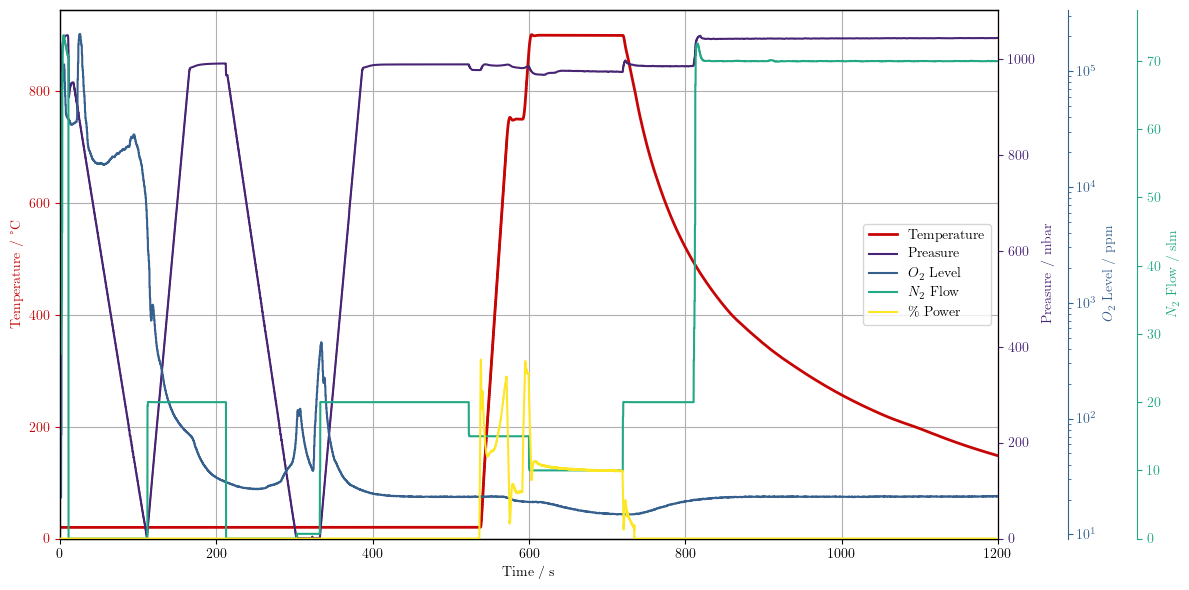

In [72]:
file_path = r"K:\tech_stud\Hager_Lutz\VS_Code\Master_data\Data\RTP\2Box_750C_20s_900C_120s_N2_2Vac_noRot.csv"
# file_path = r"..\Data\RTP\Process_9472_N2high_1000°C_2min.csv"
data = read_RTP_data(file_path=file_path)
plot_RTP_data(data, file_path)